## test new histograms locally

In [1]:
#### python
import os
import sys
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
import coffea.util
from matplotlib.colors import LogNorm
from coffea.processor import accumulate
import mplhep as hep
from helpers import merge_bkg, merge_cutflows
from helpers import *

In [2]:
# client = scaleout.make_dask_client("tls://localhost:8786")
# client

In [3]:
channels = [
    "bkg_2mulj",
    "bkg_2mulj_iso",
    "bkg_2mulj_iso_disp",
    "bkg_2mulj_iso_disp_muljdphi",
    "bkg_2mulj_iso_disp_dphi",
    "bkg_2mulj_iso_disp_muljdphi_ljmp3"
]

ch1 = channels[0]
ch2 = channels[1]
ch3 = channels[2]
ch4 = channels[3]

chan = [ch1, ch2, ch3, ch4]
runner = processor.Runner(
    # executor=processor.DaskExecutor(client=client),
    executor=processor.FuturesExecutor(),
    schema = llpnanoaodschema.LLPNanoAODSchema,
    chunksize=1000,
    # maxchunks=1,
    skipbadfiles=True,
)

p = sidm_processor.SidmProcessor(    channels,    ["BKG_study"],    unweighted_hist=True, verbose=False)

In [4]:
# signal + background
nfiles = 10

signal = fmulxy6[2:3]
fileset = utilities.make_fileset(signal, "llpNanoAOD_v2", max_files = nfiles, location_cfg="signal_4mu_v10.yaml")
out = runner.run(fileset, treename="Events", processor_instance=p)
outfmu = out["out"]

filesetttj = utilities.make_fileset(bkgttj, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
outttj     = runner.run(filesetttj, treename="Events", processor_instance=p)
outttj     = outttj["out"]

dyj = bkgdyj2
filesetdyj = utilities.make_fileset(dyj, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
outdyj     = runner.run(filesetdyj, treename="Events", processor_instance=p)
outdyj     = outdyj["out"]

qcd = bkgqcd11
filesetqcd = utilities.make_fileset(qcd, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
outqcd     = runner.run(filesetqcd, treename="Events", processor_instance=p)
outqcd     = outqcd["out"]

output = {
    **outfmu,
    **outttj,
    **outdyj,
    **outqcd
}

Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(
/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


4Mu_500GeV_5p0GeV_8p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.


...

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(
/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: divide by zero encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


QCD_Pt800To1000 is simulation. Scaling histograms or cutflows according to lumi*xs.


In [5]:
for k in output:
    print(k)
# print(signal)

4Mu_500GeV_5p0GeV_8p0mm
TTJets
DYJetsToMuMu_M50
QCD_Pt800To1000


# Different hist

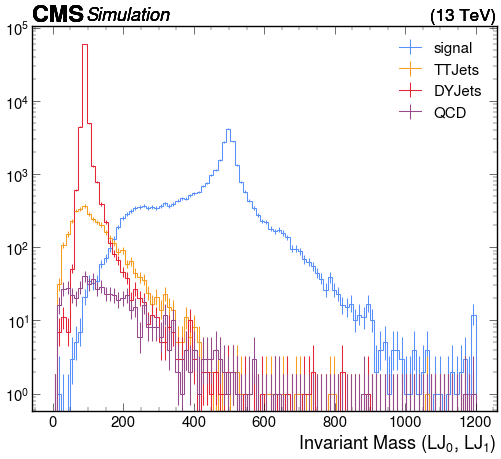

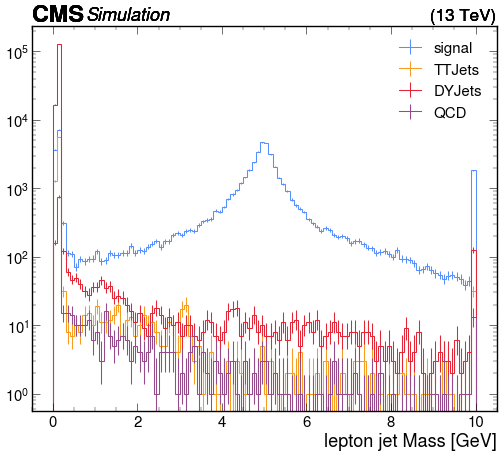

In [11]:
htoplot = ["lj_lj_invmass", "lj_mass"]#, "lj0_mass", "lj1_mass", "lj01_massdiff"]
# mutoplot = ["mu_lj_n", "mu_lj_pt"]
sss = signal[0]
for htp in htoplot:
    plt.subplots(1, 1, figsize=(12, 10))
    
    utilities.plot(output[sss]["hists"][htp][ch1, :], label="signal")
    utilities.plot(output["TTJets"]["hists"][htp][ch1, :], label = "TTJets")
    utilities.plot(output["DYJetsToMuMu_M50"]["hists"][htp][ch1, :], label = "DYJets")
    utilities.plot(output["QCD_Pt800To1000"]["hists"][htp][ch1, :], label = "QCD")
    plt.yscale("log")
    plt.legend()

# Different channels

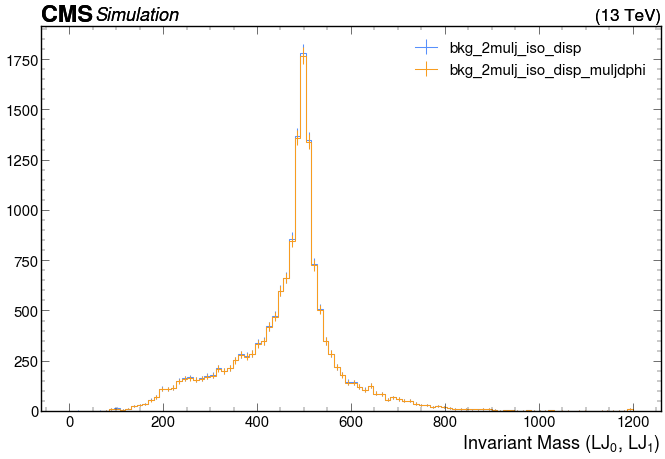

In [24]:
npl = 4
htoplot = ["lj_lj_invmass", "lj_mass","lj0_mass", "lj1_mass", "lj01_massdiff"]
htp = "lj_lj_invmass"
# mutoplot = ["mu_lj_n", "mu_lj_pt"]
sss = signal[0]
plt.subplots(1, 1, figsize=(16, 10))
for ch in chan[2:4]:
    
    plt.subplot(1, 1, 1)
    utilities.plot(output[sss]["hists"][htp][ch, :], label=ch)
    plt.legend()
    
    # plt.subplot(2, 2, 2)
    # utilities.plot(output["TTJets"]["hists"][htp][ch, :], label = ch)
    # plt.legend()
    
    # plt.subplot(2, 2, 3)
    # utilities.plot(output["DYJetsToMuMu_M50"]["hists"][htp][ch, :], label = ch)
    # plt.legend()

    # plt.subplot(2, 2, 4)
    # utilities.plot(output["QCD_Pt800To1000"]["hists"][htp][ch, :], label = ch)
    # plt.yscale("log")
    # plt.legend()

In [ ]:
nfiles = 1
qcd_samples = {
    "qcd1": bkgqcd1,
    "qcd2": bkgqcd2,
    "qcd3": bkgqcd3,
    "qcd4": bkgqcd4,
    "qcd5": bkgqcd5,
    "qcd6": bkgqcd6,
    "qcd7": bkgqcd7,
    "qcd8": bkgqcd8,
    "qcd9": bkgqcd9,
    "qcd10": bkgqcd10,
    "qcd11": bkgqcd11,
    "qcd12": bkgqcd12,
}

for name, sample in qcd_samples.items():
    print(f"Running {name}")
    fileset = utilities.make_fileset(sample, "skimmed_llpNanoAOD_v2", max_files=nfiles, location_cfg="backgrounds.yaml",)
    outqcd = runner.run(fileset, treename="Events", processor_instance=p,)
    outqcd = outqcd["out"]
    outfile = f"outputs/bkg_{vr}_{name}.coffea"
    print(f"Saving: {outfile}")
    # coffea.util.save(outqcd, outfile)